In [63]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [34]:
#Loading the dataset using pandas
data= pd.read_excel(r"C:\Users\HP\Downloads\Customer Churn-Prdiction Data.xlsx")
data


,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,Internet_Type,Online_Security,Online_Backup,Device_Protection_Plan,Premium_Support,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,52674-ODI,Male,36,Yes,Odisha,2,29,NaN,No,No,Yes,Cable,No,Yes,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,49.750000,3069.449951,0.0,0,0.000000,3069.449951,Stayed,Others,Others
1,52683-GUJ,Female,23,No,Gujarat,7,2,Deal 2,Yes,Yes,Yes,Fiber Optic,Yes,No,Yes,No,Yes,Yes,Yes,Yes,One Year,No,Bank Withdrawal,104.000000,6363.450195,0.0,0,2787.090088,9150.540039,Stayed,Others,Others
2,53303-BIH,Female,49,No,Bihar,4,31,NaN,Yes,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,Yes,Yes,No,Two Year,Yes,Bank Withdrawal,84.800003,5917.549805,0.0,120,649.599976,6687.149902,Stayed,Others,Others
3,53321-KAR,Female,68,No,Karnataka,14,25,Deal 4,Yes,No,Yes,DSL,No,No,Yes,Yes,No,No,No,Yes,Month-to-Month,No,Credit Card,-2.000000,1058.099976,0.0,0,858.960022,1917.060059,Stayed,Others,Others
4,53325-GUJ,Male,27,Yes,Gujarat,0,32,NaN,Yes,No,Yes,DSL,Yes,No,No,Yes,Yes,Yes,Yes,Yes,One Year,No,Bank Withdrawal,75.000000,1908.349976,0.0,0,1289.859985,3198.209961,Stayed,Others,Others
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6002,98151-HAR,Female,60,Yes,Haryana,10,16,Deal 2,Yes,Yes,Yes,Fiber Optic,No,No,Yes,No,No,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,92.550003,4039.000000,0.0,0,1182.069946,5221.069824,Stayed,Others,Others
6003,98159-HAR,Male,40,No,Haryana,1,25,Deal 4,Yes,Yes,Yes,Fiber Optic,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,74.349998,834.200012,0.0,0,100.540001,934.739990,Churned,Competitor,Competitor made better offer
6004,98162-TEL,Female,32,Yes,Telangana,5,7,Deal 1,Yes,No,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Two Year,No,Bank Withdrawal,85.449997,6029.899902,0.0,0,1620.930054,7650.830078,Stayed,Others,Others
6005,98168-AND,Female,52,Yes,Andhra Pradesh,1,30,NaN,Yes,No,No,NaN,No,No,No,No,No,No,No,No,Two Year,Yes,Bank Withdrawal,19.299999,1447.900024,0.0,0,1224.060059,2671.959961,Stayed,Others,Others


In [24]:
data['Customer_Status'].value_counts()

Customer_Status
Stayed     4275
Churned    1732
Name: count, dtype: int64

In [25]:
pd.set_option('display.max_columns', None)

In [35]:
# Dropping the columns we dont need for training
data.drop(columns=['Customer_ID','Churn_Category','Churn_Reason'], inplace=True)
data

,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,Internet_Type,Online_Security,Online_Backup,Device_Protection_Plan,Premium_Support,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status
0,Male,36,Yes,Odisha,2,29,NaN,No,No,Yes,Cable,No,Yes,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,49.750000,3069.449951,0.0,0,0.000000,3069.449951,Stayed
1,Female,23,No,Gujarat,7,2,Deal 2,Yes,Yes,Yes,Fiber Optic,Yes,No,Yes,No,Yes,Yes,Yes,Yes,One Year,No,Bank Withdrawal,104.000000,6363.450195,0.0,0,2787.090088,9150.540039,Stayed
2,Female,49,No,Bihar,4,31,NaN,Yes,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,Yes,Yes,No,Two Year,Yes,Bank Withdrawal,84.800003,5917.549805,0.0,120,649.599976,6687.149902,Stayed
3,Female,68,No,Karnataka,14,25,Deal 4,Yes,No,Yes,DSL,No,No,Yes,Yes,No,No,No,Yes,Month-to-Month,No,Credit Card,-2.000000,1058.099976,0.0,0,858.960022,1917.060059,Stayed
4,Male,27,Yes,Gujarat,0,32,NaN,Yes,No,Yes,DSL,Yes,No,No,Yes,Yes,Yes,Yes,Yes,One Year,No,Bank Withdrawal,75.000000,1908.349976,0.0,0,1289.859985,3198.209961,Stayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6002,Female,60,Yes,Haryana,10,16,Deal 2,Yes,Yes,Yes,Fiber Optic,No,No,Yes,No,No,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,92.550003,4039.000000,0.0,0,1182.069946,5221.069824,Stayed
6003,Male,40,No,Haryana,1,25,Deal 4,Yes,Yes,Yes,Fiber Optic,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,74.349998,834.200012,0.0,0,100.540001,934.739990,Churned
6004,Female,32,Yes,Telangana,5,7,Deal 1,Yes,No,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Two Year,No,Bank Withdrawal,85.449997,6029.899902,0.0,0,1620.930054,7650.830078,Stayed
6005,Female,52,Yes,Andhra Pradesh,1,30,NaN,Yes,No,No,NaN,No,No,No,No,No,No,No,No,Two Year,Yes,Bank Withdrawal,19.299999,1447.900024,0.0,0,1224.060059,2671.959961,Stayed


In [18]:
data

,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,Internet_Type,Online_Security,Online_Backup,Device_Protection_Plan,Premium_Support,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status
0,Male,36,Yes,Odisha,2,29,NaN,No,No,Yes,Cable,No,Yes,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,49.750000,3069.449951,0.0,0,0.000000,3069.449951,Stayed
1,Female,23,No,Gujarat,7,2,Deal 2,Yes,Yes,Yes,Fiber Optic,Yes,No,Yes,No,Yes,Yes,Yes,Yes,One Year,No,Bank Withdrawal,104.000000,6363.450195,0.0,0,2787.090088,9150.540039,Stayed
2,Female,49,No,Bihar,4,31,NaN,Yes,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,Yes,Yes,No,Two Year,Yes,Bank Withdrawal,84.800003,5917.549805,0.0,120,649.599976,6687.149902,Stayed
3,Female,68,No,Karnataka,14,25,Deal 4,Yes,No,Yes,DSL,No,No,Yes,Yes,No,No,No,Yes,Month-to-Month,No,Credit Card,-2.000000,1058.099976,0.0,0,858.960022,1917.060059,Stayed
4,Male,27,Yes,Gujarat,0,32,NaN,Yes,No,Yes,DSL,Yes,No,No,Yes,Yes,Yes,Yes,Yes,One Year,No,Bank Withdrawal,75.000000,1908.349976,0.0,0,1289.859985,3198.209961,Stayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6002,Female,60,Yes,Haryana,10,16,Deal 2,Yes,Yes,Yes,Fiber Optic,No,No,Yes,No,No,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,92.550003,4039.000000,0.0,0,1182.069946,5221.069824,Stayed
6003,Male,40,No,Haryana,1,25,Deal 4,Yes,Yes,Yes,Fiber Optic,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,74.349998,834.200012,0.0,0,100.540001,934.739990,Churned
6004,Female,32,Yes,Telangana,5,7,Deal 1,Yes,No,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Two Year,No,Bank Withdrawal,85.449997,6029.899902,0.0,0,1620.930054,7650.830078,Stayed
6005,Female,52,Yes,Andhra Pradesh,1,30,NaN,Yes,No,No,NaN,No,No,No,No,No,No,No,No,Two Year,Yes,Bank Withdrawal,19.299999,1447.900024,0.0,0,1224.060059,2671.959961,Stayed


In [36]:
# Label Encoding:
columns_to_encode=['Gender','Married','State','Value_Deal','Phone_Service','Multiple_Lines','Internet_Service',
                   'Internet_Type',	'Online_Security','Online_Backup','Device_Protection_Plan',	'Premium_Support',
                   'Streaming_TV','Streaming_Movies','Streaming_Music',	'Unlimited_Data',
                       'Contract','Paperless_Billing','Payment_Method']
# Encode categorical variables except the target variable:
label_encoders={}
for i in columns_to_encode:
    label_encoders[i]=LabelEncoder()
    data[i]= label_encoders[i].fit_transform(data[i])

# manually encode the target variable Customer status:
data['Customer_Status']=data['Customer_Status'].map({'Stayed':0,'Churned':1})


In [38]:
data

,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,Internet_Type,Online_Security,Online_Backup,Device_Protection_Plan,Premium_Support,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status
0,1,36,1,13,2,29,5,0,0,1,0,0,1,0,0,1,1,1,1,0,1,0,49.750000,3069.449951,0.0,0,0.000000,3069.449951,0
1,0,23,0,5,7,2,1,1,1,1,2,1,0,1,0,1,1,1,1,1,0,0,104.000000,6363.450195,0.0,0,2787.090088,9150.540039,0
2,0,49,0,2,4,31,5,1,1,1,1,0,1,1,1,1,1,1,0,2,1,0,84.800003,5917.549805,0.0,120,649.599976,6687.149902,0
3,0,68,0,9,14,25,3,1,0,1,1,0,0,1,1,0,0,0,1,0,0,1,-2.000000,1058.099976,0.0,0,858.960022,1917.060059,0
4,1,27,1,5,0,32,5,1,0,1,1,1,0,0,1,1,1,1,1,1,0,0,75.000000,1908.349976,0.0,0,1289.859985,3198.209961,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6002,0,60,1,6,10,16,1,1,1,1,2,0,0,1,0,0,1,1,1,0,1,0,92.550003,4039.000000,0.0,0,1182.069946,5221.069824,0
6003,1,40,0,6,1,25,3,1,1,1,2,0,0,0,0,0,0,0,1,0,1,0,74.349998,834.200012,0.0,0,100.540001,934.739990,1
6004,0,32,1,18,5,7,0,1,0,1,1,1,1,1,1,1,1,1,1,2,0,0,85.449997,6029.899902,0.0,0,1620.930054,7650.830078,0
6005,0,52,1,0,1,30,5,1,0,0,3,0,0,0,0,0,0,0,0,2,1,0,19.299999,1447.900024,0.0,0,1224.060059,2671.959961,0


In [41]:
# split the data into features and target variable:
x=data.drop( columns=['Customer_Status'], axis=1)
y=data['Customer_Status']

In [42]:
x

,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,Internet_Type,Online_Security,Online_Backup,Device_Protection_Plan,Premium_Support,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue
0,1,36,1,13,2,29,5,0,0,1,0,0,1,0,0,1,1,1,1,0,1,0,49.750000,3069.449951,0.0,0,0.000000,3069.449951
1,0,23,0,5,7,2,1,1,1,1,2,1,0,1,0,1,1,1,1,1,0,0,104.000000,6363.450195,0.0,0,2787.090088,9150.540039
2,0,49,0,2,4,31,5,1,1,1,1,0,1,1,1,1,1,1,0,2,1,0,84.800003,5917.549805,0.0,120,649.599976,6687.149902
3,0,68,0,9,14,25,3,1,0,1,1,0,0,1,1,0,0,0,1,0,0,1,-2.000000,1058.099976,0.0,0,858.960022,1917.060059
4,1,27,1,5,0,32,5,1,0,1,1,1,0,0,1,1,1,1,1,1,0,0,75.000000,1908.349976,0.0,0,1289.859985,3198.209961
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6002,0,60,1,6,10,16,1,1,1,1,2,0,0,1,0,0,1,1,1,0,1,0,92.550003,4039.000000,0.0,0,1182.069946,5221.069824
6003,1,40,0,6,1,25,3,1,1,1,2,0,0,0,0,0,0,0,1,0,1,0,74.349998,834.200012,0.0,0,100.540001,934.739990
6004,0,32,1,18,5,7,0,1,0,1,1,1,1,1,1,1,1,1,1,2,0,0,85.449997,6029.899902,0.0,0,1620.930054,7650.830078
6005,0,52,1,0,1,30,5,1,0,0,3,0,0,0,0,0,0,0,0,2,1,0,19.299999,1447.900024,0.0,0,1224.060059,2671.959961


In [43]:
y

0       0
1       0
2       0
3       0
4       0
       ..
6002    0
6003    1
6004    0
6005    0
6006    1
Name: Customer_Status, Length: 6007, dtype: int64

In [45]:
# Split data into training and testing sets:
x_train, x_test,y_train, y_test= train_test_split(x,y,test_size=0.2, random_state=42)


In [46]:
# Model Creation:
model= RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train,y_train)


RandomForestClassifier(random_state=42)

In [47]:
# Evaluating the Model:
# Make Prediactions:
y_pred=model.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 1], dtype=int64)

In [48]:
y_test

79      0
3043    0
4851    0
1168    0
3573    0
       ..
2746    1
4374    0
3378    0
1554    0
2673    1
Name: Customer_Status, Length: 1202, dtype: int64

In [50]:
accuracy_score(y_test,y_pred)

0.8452579034941764

In [58]:
# Confusion Matrix and Clssification Report:
print("Confusion Matrix:")
print(confusion_matrix(y_test,y_pred))




Confusion Matrix:
[[792  53]
 [133 224]]


In [60]:
print("\nClassification report")
print(classification_report(y_test,y_pred))


Classification report
              precision    recall  f1-score   support

           0       0.86      0.94      0.89       845
           1       0.81      0.63      0.71       357

    accuracy                           0.85      1202
   macro avg       0.83      0.78      0.80      1202
weighted avg       0.84      0.85      0.84      1202



In [61]:
# Feature selection using feature importance:
importances= model.feature_importances_
indices= np.argsort(importances)[::-1]

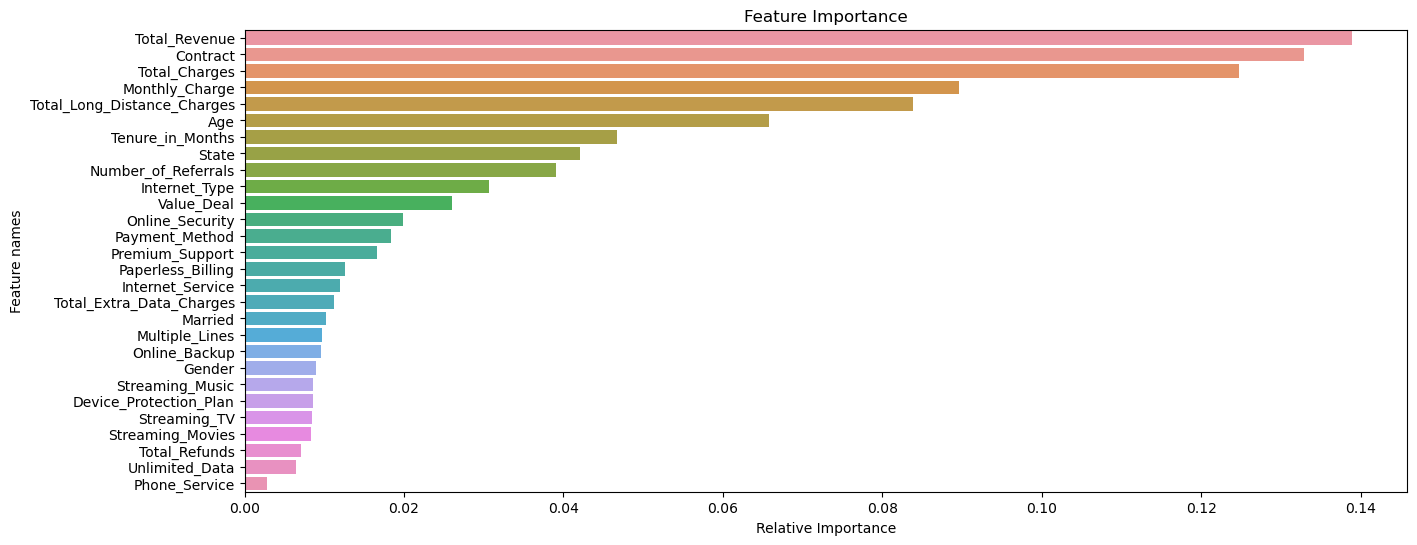

In [65]:
# Plot the feature importnace:
plt.figure(figsize=(15,6))
sns.barplot(x=importances[indices],y=x.columns[indices])
plt.title('Feature Importance')
plt.xlabel('Relative Importance')
plt.ylabel('Feature names')
plt.show()

In [66]:
# Predict for new data
new_data=pd.read_excel(r"C:\Users\HP\Downloads\Customer Churn-Prdiction Data.xlsx", sheet_name='Joined data')
new_data

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,Internet_Type,Online_Security,Online_Backup,Device_Protection_Plan,Premium_Support,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,53350-TEL,Male,37,Yes,Telangana,6,22,NaN,Yes,Yes,Yes,Fiber Optic,No,No,No,No,No,No,No,Yes,Month-to-Month,No,Bank Withdrawal,74.500000,217.449997,0.0,0,20.910000,238.360001,Joined,Others,Others
1,53449-MAH,Female,52,No,Maharashtra,8,17,NaN,Yes,No,No,NaN,No,No,No,No,No,No,No,No,Month-to-Month,No,Credit Card,19.900000,19.900000,0.0,0,2.380000,22.280001,Joined,Others,Others
2,54997-UTT,Female,55,No,Uttar Pradesh,7,23,NaN,Yes,No,Yes,DSL,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,44.000000,44.000000,0.0,0,26.150000,70.150002,Joined,Others,Others
3,56256-UTT,Male,40,No,Uttar Pradesh,14,15,NaN,Yes,No,Yes,Fiber Optic,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,70.300003,220.399994,0.0,0,29.219999,249.619995,Joined,Others,Others
4,58974-MAD,Male,34,No,Madhya Pradesh,11,14,NaN,Yes,No,No,NaN,No,No,No,No,No,No,No,No,Month-to-Month,No,Credit Card,20.299999,41.200001,0.0,0,25.360001,66.559998,Joined,Others,Others
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,92228-BIH,Female,22,Yes,Bihar,10,9,NaN,No,No,Yes,Cable,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,25.150000,25.150000,0.0,0,0.000000,25.150000,Joined,Others,Others
407,94070-JAM,Female,21,Yes,Jammu & Kashmir,8,3,NaN,Yes,No,Yes,Fiber Optic,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,90.099998,90.099998,0.0,0,24.330000,114.430000,Joined,Others,Others
408,94124-MAH,Female,21,No,Maharashtra,9,8,NaN,Yes,No,Yes,Fiber Optic,No,No,No,No,Yes,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,79.949997,174.449997,0.0,0,75.400002,249.850006,Joined,Others,Others
409,94243-TAM,Female,34,No,Tamil Nadu,5,15,NaN,Yes,No,No,NaN,No,No,No,No,No,No,No,No,Month-to-Month,Yes,Credit Card,19.900000,19.900000,0.0,0,7.760000,27.660000,Joined,Others,Others


In [67]:
new_data['Customer_Status'].value_counts()

Customer_Status
Joined    411
Name: count, dtype: int64

In [68]:
# Retain the original dataframe to preserve unencoded columns
original_new_data=new_data.copy()

In [69]:
# retain the customer id column
customer_ids= new_data['Customer_ID']

In [70]:
# Drop columns that wont be used for prediction in encoded dataframe:
new_data.drop(columns=['Customer_ID','Churn_Category','Churn_Reason','Customer_Status'], inplace=True)

In [71]:
# Encode categorical variables :
for i in new_data.select_dtypes(include=['object']).columns:
    new_data[i]= label_encoders[i].transform(new_data[i])

In [72]:
# make predictions:
new_predictions=model.predict(new_data)

In [73]:
new_predictions

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [75]:
# Add predictions to the original dataframe:
original_new_data['customer_status_predicted']=new_predictions

In [76]:
# Filter the dataframe to include only records predicted as churned:
original_new_data=original_new_data[original_new_data['customer_status_predicted']==1]

In [78]:
# save the results:
original_new_data.to_excel(r"C:\Users\HP\Downloads\Prediction file.xlsx")